<a href="https://colab.research.google.com/github/JDVAR7/IA-Intermedio/blob/main/Entregable4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#                                        ***ENTREGABLE 4***


## Objetivos del Laboratorio:
1. El objetivo de este laboratorio es adquirir experiencia práctica en la implementación de un proceso básico de MapReduce utilizando un entorno distribuido con Hadoop.

2. Comprender y aplicar el paradigma de MapReduce en el procesamiento de datos en un entorno distribuido.

3. Implementar una solución básica de MapReduce utilizando Hadoop en Docker.

4. Evaluar la eficiencia del proceso MapReduce y entender cómo puede escalar a grandes volúmenes de datos.

5. Aplicar MapReduce para resolver problemas sencillos de procesamiento de datos, como el conteo de palabras o la agregación de datos.


¿Por qué usar Hadoop y MapReduce?

Hadoop y MapReduce se utilizan cuando los datos son demasiado grandes para procesarlos en una sola computadora. Hadoop permite distribuir el almacenamiento (HDFS) y el cálculo (MapReduce) en un clúster de cientos o miles de máquinas económicas. Las ventajas principales:

Escalabilidad, Tolerancia a fallos, Procesamiento cerca de los datos, Simplicidad del modelo MapReduce

Ejemplo práctico del laboratorio:
Aunque usamos un archivo pequeño (Lab_Hadoop con una línea), el mismo código funcionaría con terabytes de datos distribuidos en cientos de nodos. Hadoop se encargaría de dividir automáticamente el archivo en fragmentos (splits), ejecutar los mappers en paralelo y luego los reducers, agregando los resultados parciales.

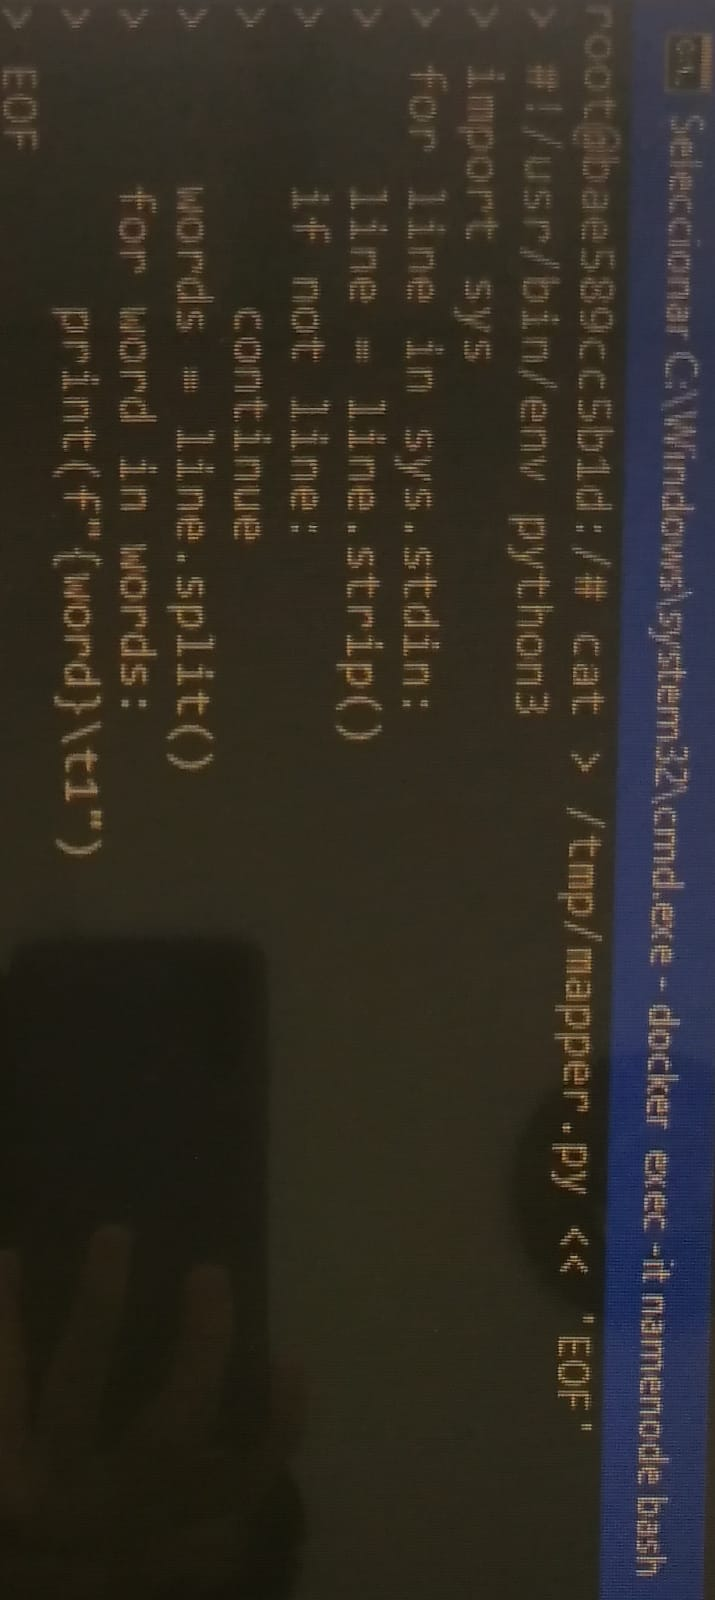

# **↑** Recreación del mapper.py

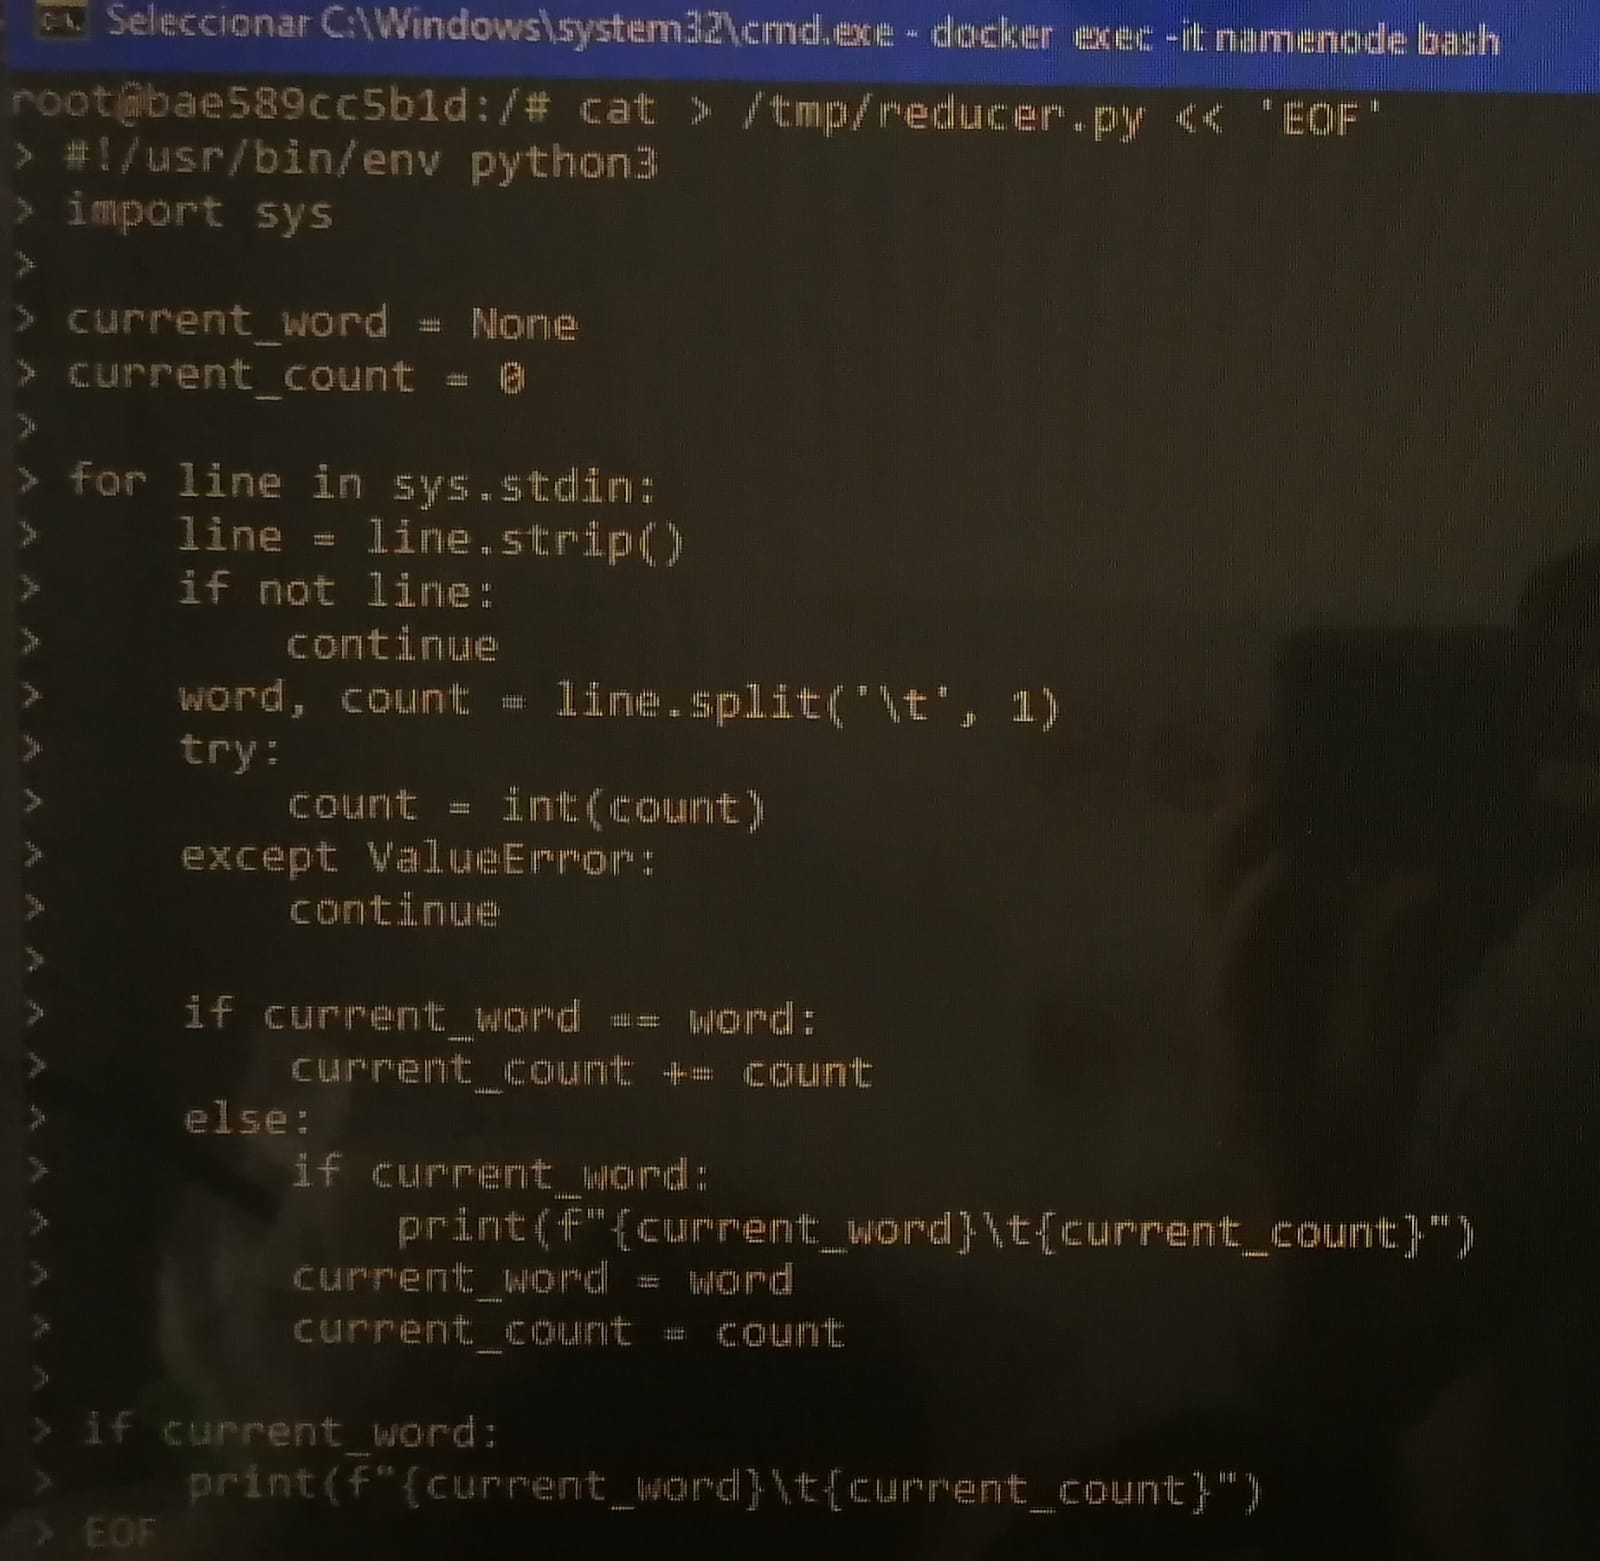

## **↑** recreación del reducer.py

▶

### Distribución de datos en Hadoop Streaming

En Hadoop Streaming, la distribución de datos sigue el mismo principio que en MapReduce tradicional, pero con la flexibilidad de usar cualquier ejecutable o script (en nuestro caso, Python).

Fase de división (Input Splits):
El archivo de entrada (en HDFS) se divide lógicamente en splits (por defecto, de 128 MB cada uno). Cada split se asigna a una tarea Map diferente.

Fase Map (mapeo):
Cada nodo lee su split línea por línea y envía cada línea al script mapper (Python). El mapper emite pares (clave, valor) que se almacenan temporalmente en el disco local del nodo.

Fase Shuffle y Sort (automática):
Hadoop agrupa automáticamente todas las salidas de los mappers por clave, las ordena y las envía a los nodos Reducer correspondientes. Este proceso es transparente para el programador.

Fase Reduce:
Cada nodo Reducer recibe un conjunto de claves con sus listas de valores y ejecuta el script reducer (Python), produciendo el resultado final en HDFS.

#### Conclusión: Hadoop Streaming distribuye tanto los datos como la ejecución de los scripts, aprovechando el clúster completo sin que el programador tenga que gestionar la comunicación ni la paralelización.

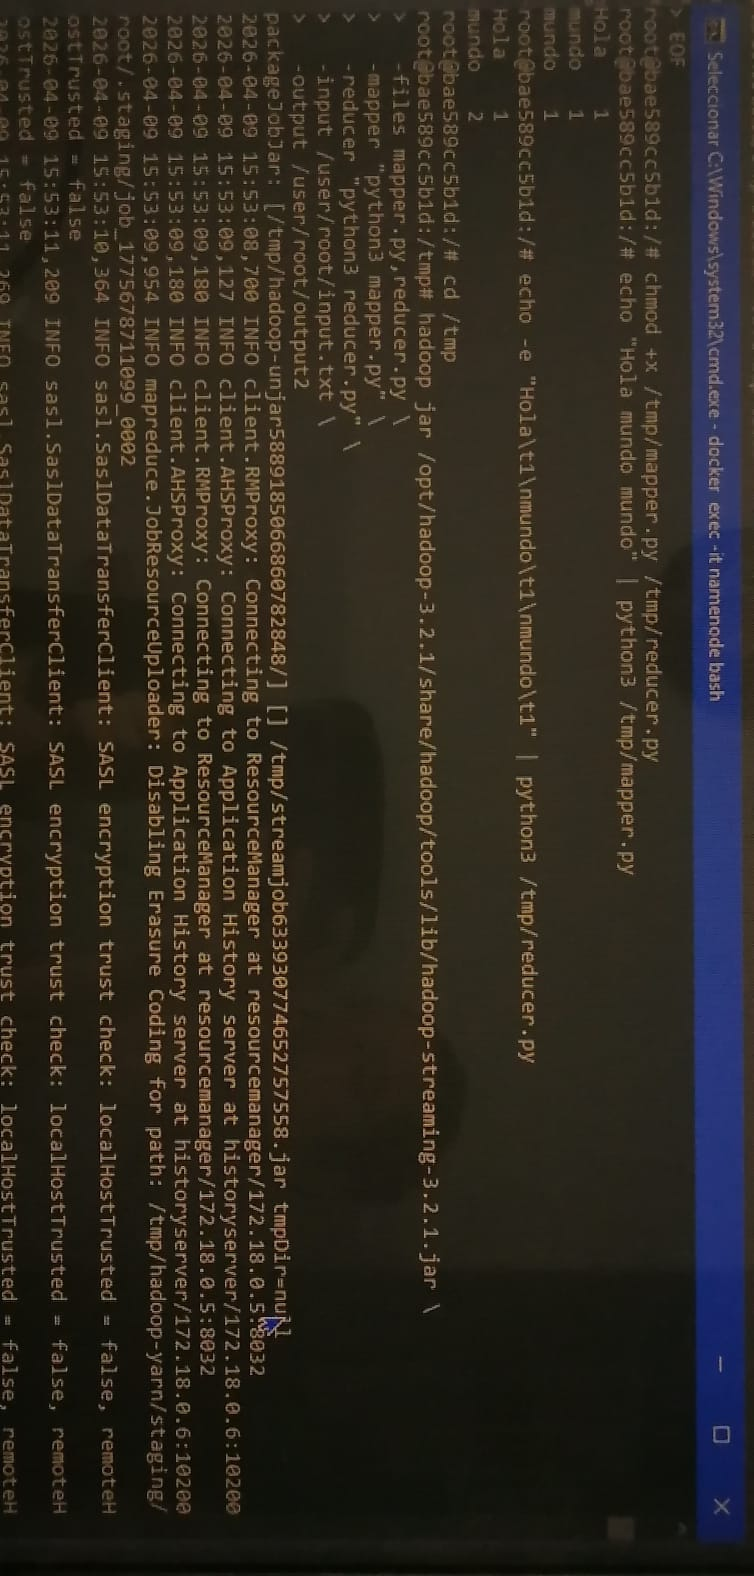

## **↑** permiso de ejecución...

    Prueba del mapper y prueba del reducer

### inicio de ejecución del hadoop Streaming


2026-04-09 15:53:47,228 INFO streaming.StreamJob: Output directory: /user/root/output2

root@bae589cc5b1d:/tmp# hdfs dfs -cat /user/root/output2/part-00000

2026-04-09 15:56:57,109 INFO sasl.SaslDataTransferClient: SASL encryption trust check: localHostTrusted = false, remoteHostTrusted = false

    Hadoop  1
    Hola    1
    desde   1
    mundo   2

root@bae589cc5b1d:/tmp#

### **↑** ejecución exitosa del hadoop Streaming

⛲

¿Por qué no simplemente usar Python?

Python puro (sin Hadoop) funciona bien para archivos pequeños o medianos que caben en la memoria RAM de una sola computadora. Sin embargo, cuando los datos alcanzan escala de Big Data (terabytes o petabytes)

Analogía:

Python solo es como un chef que cocina una pizza entera en un horno pequeño.

Hadoop + MapReduce es como una cocina industrial con muchos chefs (mappers) que preparan porciones en paralelo y un supervisor (reducer) que ensambla el resultado final.

En el laboratorio, usamos Python dentro de Hadoop Streaming para aprovechar lo mejor de ambos mundos: la facilidad de Python y el poder de cómputo distribuido de Hadoop.

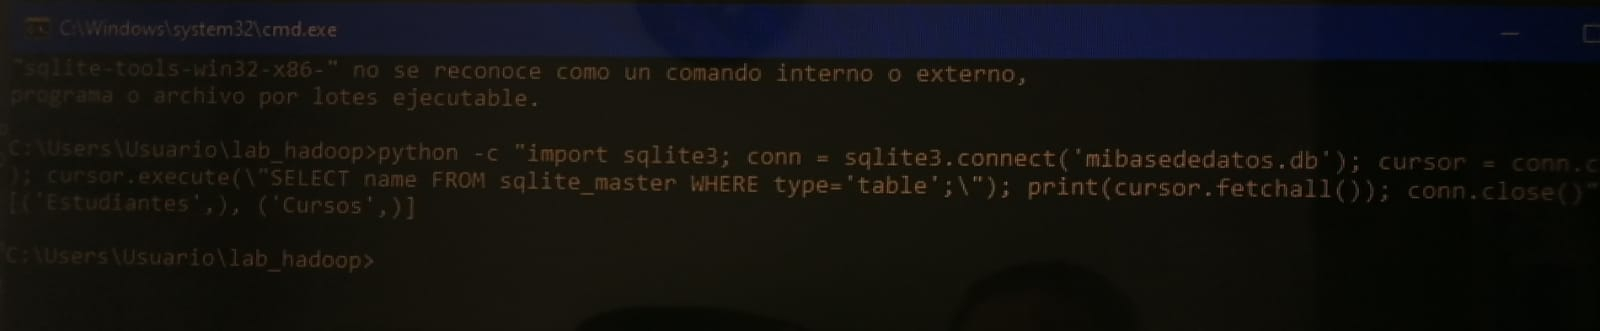

## **↑**

import sqlite3

# Conectar a la base de datos (creandola si no existe)
conexion = sqlite3.connect('mibasededatos.db')
cursor = conexion.cursor()

# Crear tabla Estudiantes
cursor.execute('''
CREATE TABLE IF NOT EXISTS Estudiantes (
    ID INTEGER PRIMARY KEY,
    Nombre TEXT NOT NULL,
    Edad INTEGER NOT NULL,
    Carrera TEXT NOT NULL
)
''')

# Crear tabla Cursos
cursor.execute('''
CREATE TABLE IF NOT EXISTS Cursos (
    CursoID INTEGER PRIMARY KEY,
    Nombre TEXT NOT NULL,
    Creditos INTEGER NOT NULL
)
''')

# Guardar cambios y cerrar
conexion.commit()
print("Tablas creadas correctamente.")
conexion.close()

## ***Reto 2***

In [3]:
# Descargamos un libro de dominio público (Ej: Los Miserables)
import urllib.request

url = "https://www.gutenberg.org/files/135/135-0.txt"  # Los Miserables
print("Descarga de archivo...")
response = urllib.request.urlopen(url)
data = response.read().decode('utf-8', errors='ignore')

# Guardamos en el entorno de Colab
with open('input.txt', 'w', encoding='utf-8') as f:
    f.write(data)

print(f"Archivo descargado y guardado. Tamaño: {len(data)} caracteres.")

Descarga de archivo...
Archivo descargado y guardado. Tamaño: 3304686 caracteres.


In [4]:
# Función Mapper y ejecución sobre el archivo
from collections import defaultdict

def mapper(line):
    """Recibe una línea de texto, devuelve lista de (palabra, 1)"""
    palabras = line.strip().split()
    # Limpiamos palabras: elimina puntuación y pasa a minúsculas
    resultado = []
    for p in palabras:
        limpia = ''.join(c for c in p if c.isalpha()).lower()
        if limpia:  # si no queda vacía
            resultado.append((limpia, 1))
    return resultado

# Aplicamos mapper a cada línea del archivo
mapped_pairs = []
with open('input.txt', 'r', encoding='utf-8', errors='ignore') as f:
    for linea in f:
        mapped_pairs.extend(mapper(linea))

print(f"Fase de Map completada. Pares generados: {len(mapped_pairs)}")

Fase de Map completada. Pares generados: 564368


In [5]:
# Shuffle (agrupamos por clave) y Reduce (sumar valores)
shuffle_dict = defaultdict(list)
for palabra, valor in mapped_pairs:
    shuffle_dict[palabra].append(valor)

# Reduce: sumamos los valores de cada palabra
resultado = []
for palabra, lista_valores in shuffle_dict.items():
    resultado.append((palabra, sum(lista_valores)))

# Ordenamos de mayor a menor frecuencia
resultado.sort(key=lambda x: x[1], reverse=True)

# Se muestra las 20 palabras más frecuentes
print("\n=== TOP 20 PALABRAS MÁS FRECUENTES ===\n")
for i, (palabra, frecuencia) in enumerate(resultado[:20], 1):
    print(f"{i:2d}. {palabra:15s} -> {frecuencia} ocurrencias")


=== TOP 20 PALABRAS MÁS FRECUENTES ===

 1. the             -> 40563 ocurrencias
 2. of              -> 19809 ocurrencias
 3. and             -> 14810 ocurrencias
 4. a               -> 14361 ocurrencias
 5. to              -> 13624 ocurrencias
 6. in              -> 11116 ocurrencias
 7. he              -> 9576 ocurrencias
 8. was             -> 8612 ocurrencias
 9. that            -> 7754 ocurrencias
10. it              -> 6461 ocurrencias
11. his             -> 6458 ocurrencias
12. had             -> 6172 ocurrencias
13. is              -> 6160 ocurrencias
14. which           -> 5127 ocurrencias
15. with            -> 4479 ocurrencias
16. on              -> 4451 ocurrencias
17. at              -> 4038 ocurrencias
18. this            -> 3925 ocurrencias
19. not             -> 3777 ocurrencias
20. you             -> 3592 ocurrencias


###¿Por qué este proceso simula MapReduce?

Porque separa claramente las fases:
    Map (generar pares clave-valor),
    Shuffle (agrupar por clave) y
    Reduce (sumar).

Aunque se ejecuta en una sola máquina, el algoritmo es el mismo que usaría Hadoop en un clúster.

### ¿Qué ventaja tiene usar Hadoop sobre este script?

Este script funciona solo para archivos que caben en memoria RAM y en un solo ordenador. Hadoop distribuiría el archivo en bloques, ejecutaría los mappers en paralelo en muchos nodos y manejaría fallos automáticamente.

### ¿Cómo podrías mejorar el script para procesar archivos más grandes que la RAM?

Se podría procesar el archivo línea por línea sin guardar todos los pares en memoria, usando un diccionario parcial y escribiendo a disco cuando se llene, similar a lo que hace Hadoop con los "spills".